# 05 — Explainability with SHAP

## Objective

Explain the saved winning model from Notebook 04 at both the portfolio and applicant levels. This notebook does not train a separate model.

> Run `04_modeling.ipynb` first so that `models/best_model.joblib` and its metadata are available.


## Business lens

Explainability makes model output usable in a credit-risk workflow. Portfolio-level explanations help risk teams understand which factors influence model behaviour; applicant-level explanations support analyst investigation of a specific estimate.

| Explanation level | Audience | Business use |
| --- | --- | --- |
| Global | Risk managers and model validators | Challenge whether model behaviour is plausible and stable. |
| Local | Credit analysts | Investigate the factors that influenced one risk estimate. |

> SHAP explains the model's behaviour on the available data. It does not prove causality, validate a policy decision, or replace an adverse-action process.


In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import train_test_split

from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "Raw"
PROCESSED_DATA_DIR = DATA_DIR / "Processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

metadata_path = MODELS_DIR / "best_model_metadata.json"
model_path = MODELS_DIR / "best_model.joblib"

if not metadata_path.exists() or not model_path.exists():
    raise FileNotFoundError("Run 04_modeling.ipynb before this notebook.")

metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
pipeline = joblib.load(model_path)
print(f"Loaded selected model: {metadata['best_model']}")


Loaded selected model: HistGradientBoosting


In [2]:
train = pd.read_csv(PROCESSED_DATA_DIR / "train_feature_engineered.csv")
target = train["TARGET"]
features = train.reindex(columns=metadata["feature_columns"]).replace([np.inf, -np.inf], np.nan)

X_train, X_test, _, _ = train_test_split(
    features,
    target,
    test_size=metadata["test_size"],
    stratify=target,
    random_state=metadata["random_state"],
)

if "imputer" not in pipeline.named_steps:
    raise RuntimeError("The saved pipeline must contain an imputer for explainability.")

imputer = pipeline.named_steps["imputer"]
estimator = pipeline.named_steps["model"]
X_train_ready = pd.DataFrame(imputer.transform(X_train), columns=features.columns, index=X_train.index)
X_test_ready = pd.DataFrame(imputer.transform(X_test), columns=features.columns, index=X_test.index)


## Global explanation

SHAP values describe how features move model output relative to the baseline. They do not imply causation or establish a credit-decision policy.


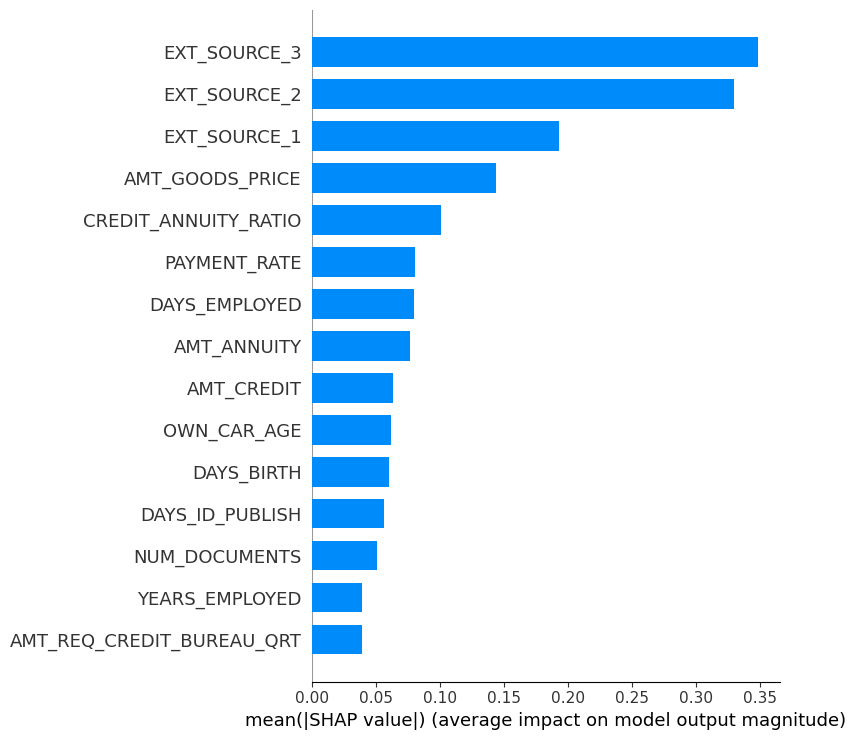

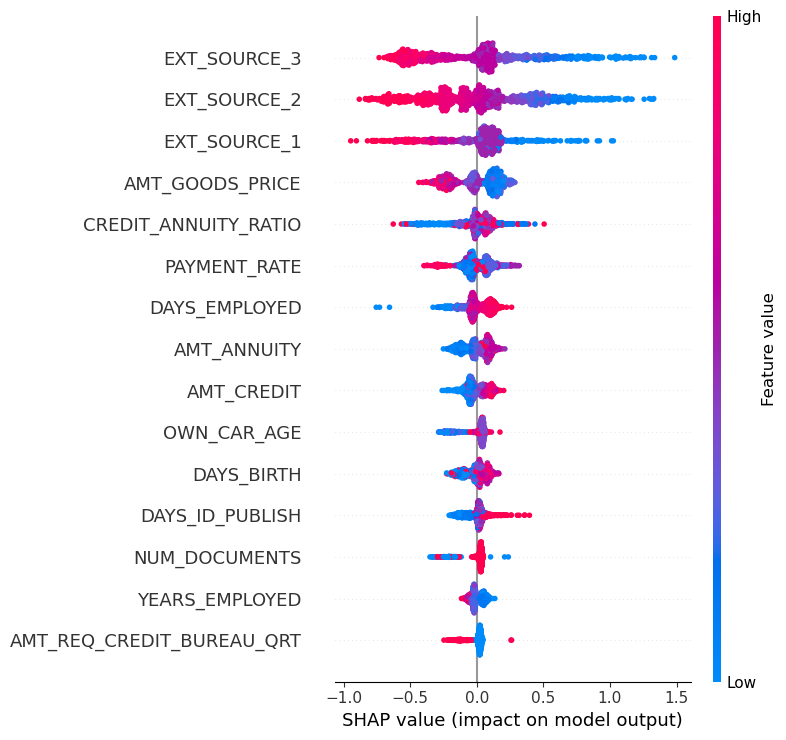

In [3]:
if metadata["best_model"] != "HistGradientBoosting":
    raise RuntimeError(
        "This notebook is configured for the HistGradientBoosting winner. "
        "Update the SHAP explainer if a different model wins after retraining."
    )

sample_size = min(1_000, len(X_test_ready))
X_sample = X_test_ready.sample(sample_size, random_state=metadata["random_state"])

explainer = shap.TreeExplainer(estimator)
raw_shap_values = explainer.shap_values(X_sample)

if isinstance(raw_shap_values, list):
    shap_values = raw_shap_values[1]
elif np.ndim(raw_shap_values) == 3:
    shap_values = raw_shap_values[:, :, 1]
else:
    shap_values = raw_shap_values

shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=15)
shap.summary_plot(shap_values, X_sample, max_display=15)


## Local explanation

The waterfall chart explains one test-set applicant. Use it to support review; it must not be used as an automated adverse-action notice.


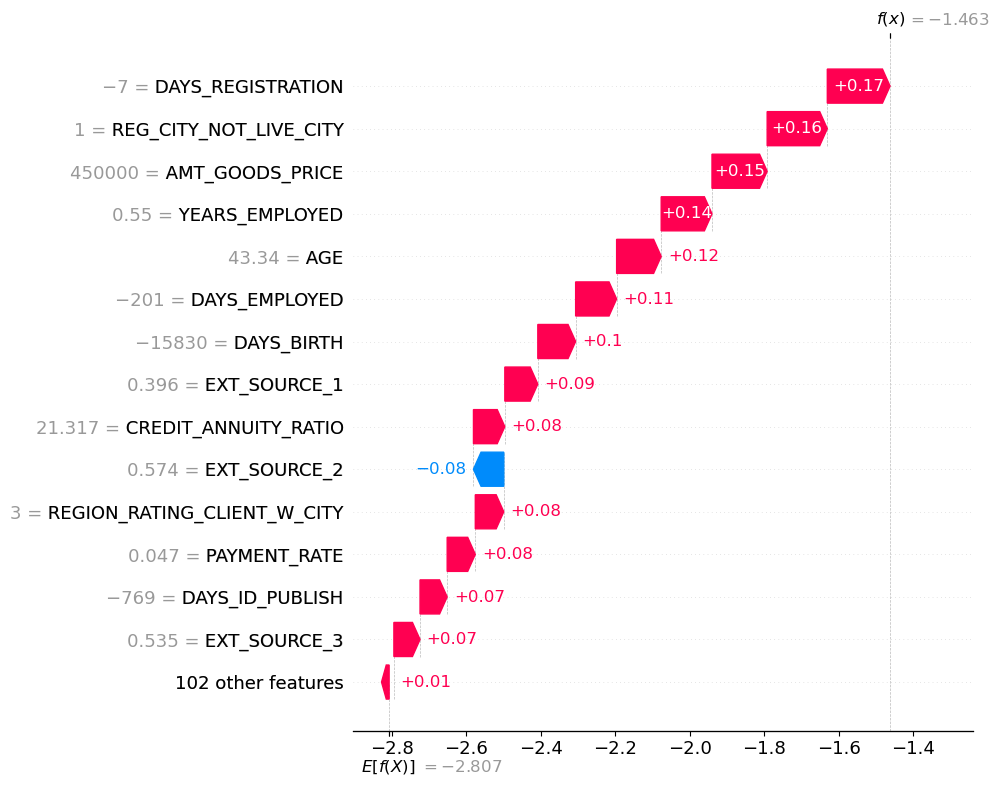

In [4]:
applicant_position = 0
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.asarray(base_value).reshape(-1)[-1]

applicant_explanation = shap.Explanation(
    values=shap_values[applicant_position],
    base_values=base_value,
    data=X_sample.iloc[applicant_position],
    feature_names=X_sample.columns,
)
shap.plots.waterfall(applicant_explanation, max_display=15)


## Interpretation safeguards

- Review explanations alongside input quality and business policy.
- Monitor feature drift and model performance after deployment.
- Test fairness and adverse-impact risk before using the model for real credit decisions.


## Analyst guidance

Use explanations as one input to human review. A production workflow should pair them with verified source data, model monitoring, fairness testing, documented policy rules, and appropriate customer communication.
